In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


sns.set_theme(style='whitegrid',palette='muted')

db_path = Path('../data/db/blue_mf.db')
con = sqlite3.connect(db_path)

print('connected')

connected


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20416\1721396838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_aum,x='max_aum',y='fund_house',palette='Blues_r')


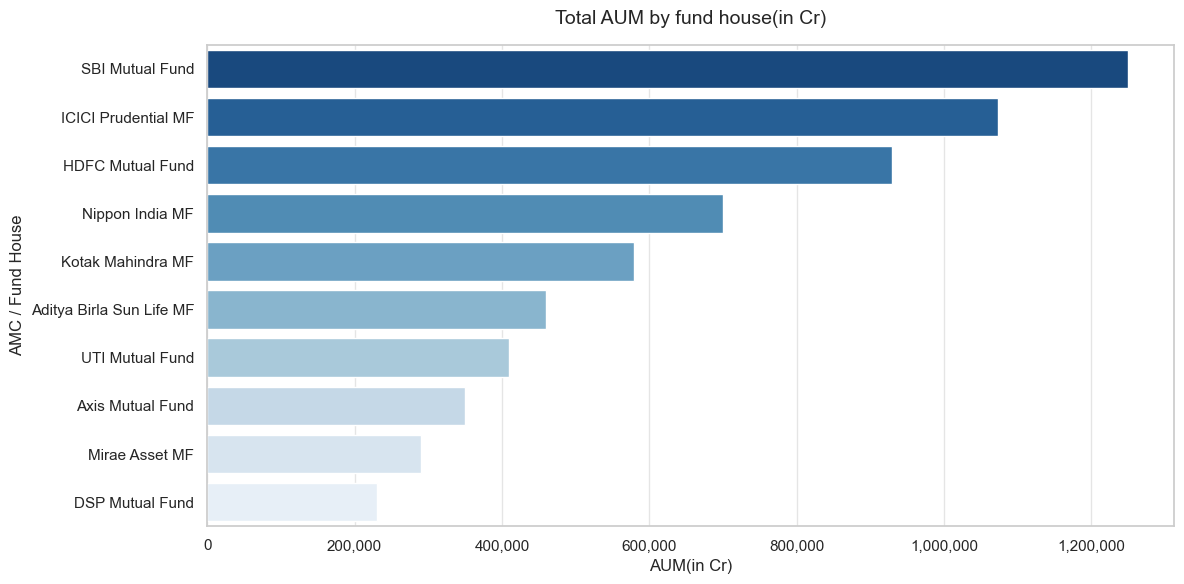

In [3]:
query = """
     SELECT fund_house, MAX(aum_crore) as max_aum
     FROM fact_aum
     GROUP BY fund_house
     ORDER BY max_aum DESC
"""

df_aum = pd.read_sql(query,con)

plt.figure(figsize=(12,6))
ax = sns.barplot(data=df_aum,x='max_aum',y='fund_house',palette='Blues_r')

plt.title('Total AUM by fund house(in Cr)',fontsize=14,pad = 15)
plt.xlabel('AUM(in Cr)',fontsize=12)
plt.ylabel('AMC / Fund House',fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))

plt.tight_layout()
plt.show()

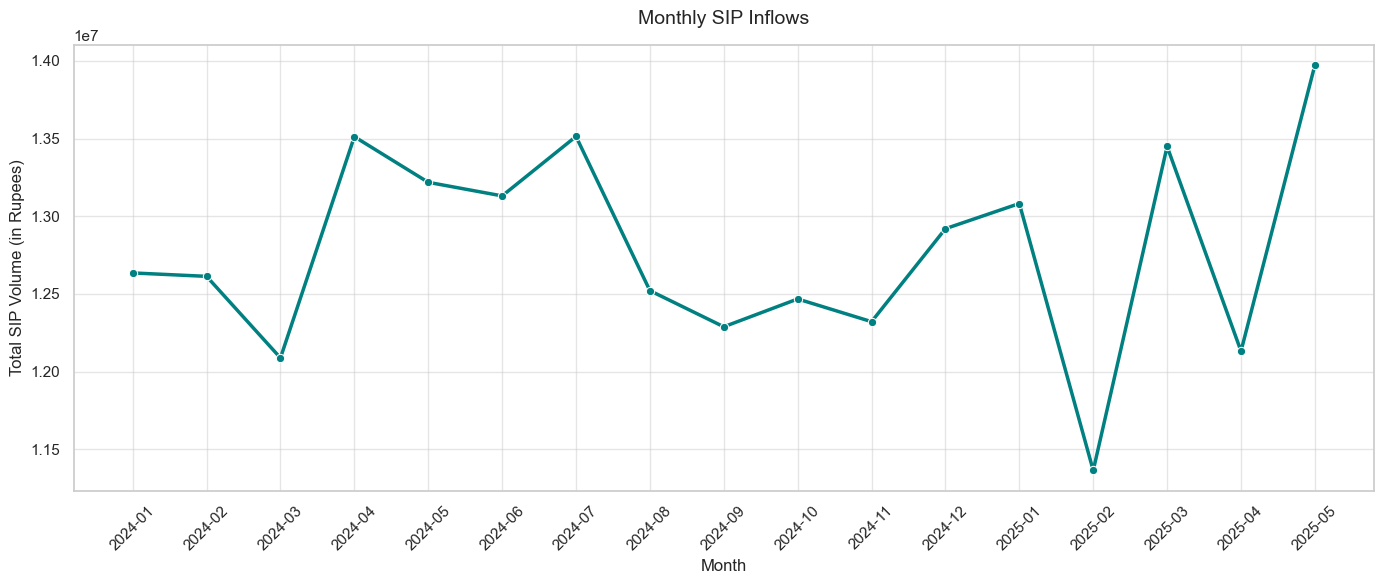

In [7]:
#sip growth trend
query = """
SELECT strftime('%Y-%m',transaction_date) AS month,SUM(amount_inr) as total_sip_vol
FROM fact_transactions
WHERE transaction_type = 'Sip'
GROUP BY month
ORDER BY month
"""
df_sip = pd.read_sql(query,con)


plt.figure(figsize=(14,6))
sns.lineplot(data=df_sip,x='month',y='total_sip_vol',marker='o',color='teal',linewidth=2.5)

plt.title('Monthly SIP Inflows',fontsize=14,pad=15)
plt.xlabel('Month',fontsize=12)
plt.ylabel('Total SIP Volume (in Rupees)',fontsize=12)

plt.xticks(rotation=45)

# plt.fill_between(df_sip['month'],df_sip['total_sip_vol'],color='teal',alpha=0.1)

plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20416\4111264344.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sip,x='age_group',y='amount_inr',order=age_order,ax=axes[1],palette='crest')


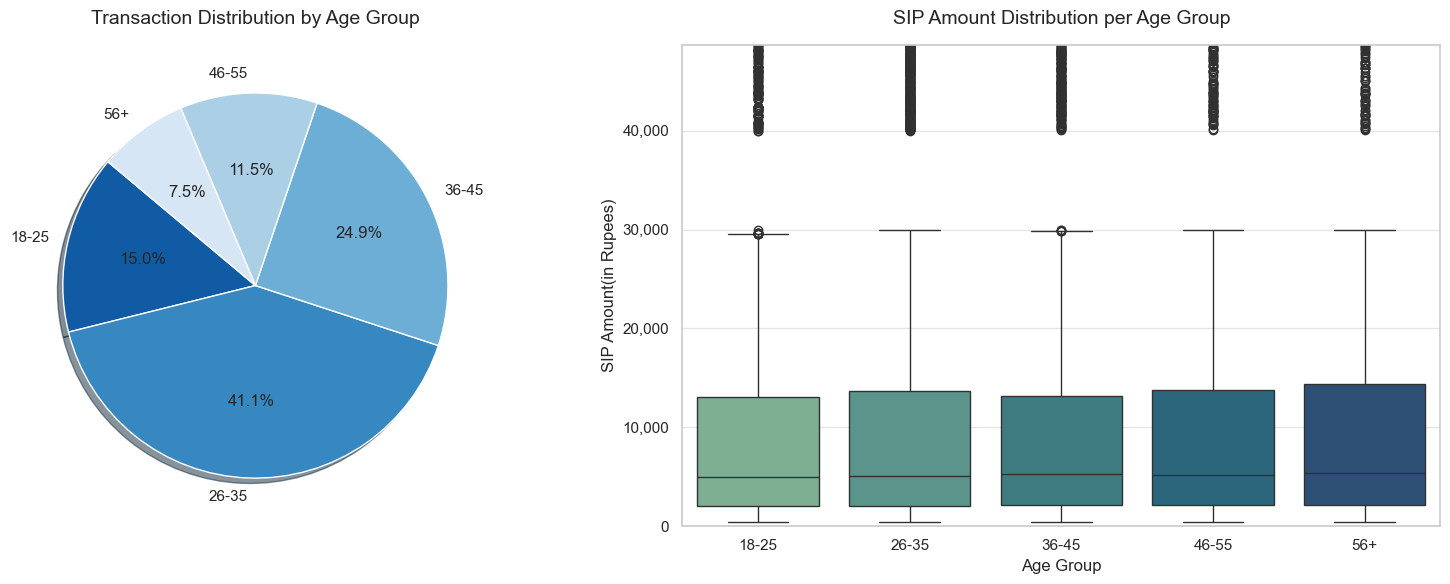

In [13]:
import matplotlib.ticker as ticker
# distribution of investors by age

query_age = """
SELECT age_group,COUNT(*) as tx_count
FROM fact_transactions
GROUP BY age_group
order by age_group
"""

df_age = pd.read_sql(query_age,con)

# raw sip box plot
query_sip = """
SELECT age_group,amount_inr
FROM fact_transactions
WHERE transaction_type = 'Sip'
"""

df_sip = pd.read_sql(query_sip,con)

fig,axes = plt.subplots(1,2,figsize=(16,6))
colors = sns.color_palette("Blues_r",len(df_age))
axes[0].pie(df_age['tx_count'],labels=df_age['age_group'],autopct='%1.1f%%',startangle=140,colors=colors,shadow=True,wedgeprops={'edgecolor':'white'})
axes[0].set_title('Transaction Distribution by Age Group',fontsize=14,pad=15)

age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
sns.boxplot(data=df_sip,x='age_group',y='amount_inr',order=age_order,ax=axes[1],palette='crest')
axes[1].set_title('SIP Amount Distribution per Age Group',fontsize=14,pad=15)
axes[1].set_xlabel('Age Group',fontsize=12)
axes[1].set_ylabel('SIP Amount(in Rupees)',fontsize=12)

y_cap = df_sip['amount_inr'].quantile(0.95)
axes[1].set_ylim(0,y_cap)

axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,pos:f'{int(x):,}'))
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20416\3993962318.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_state,x='total_volume',y='state',ax=axes[0],palette='viridis')


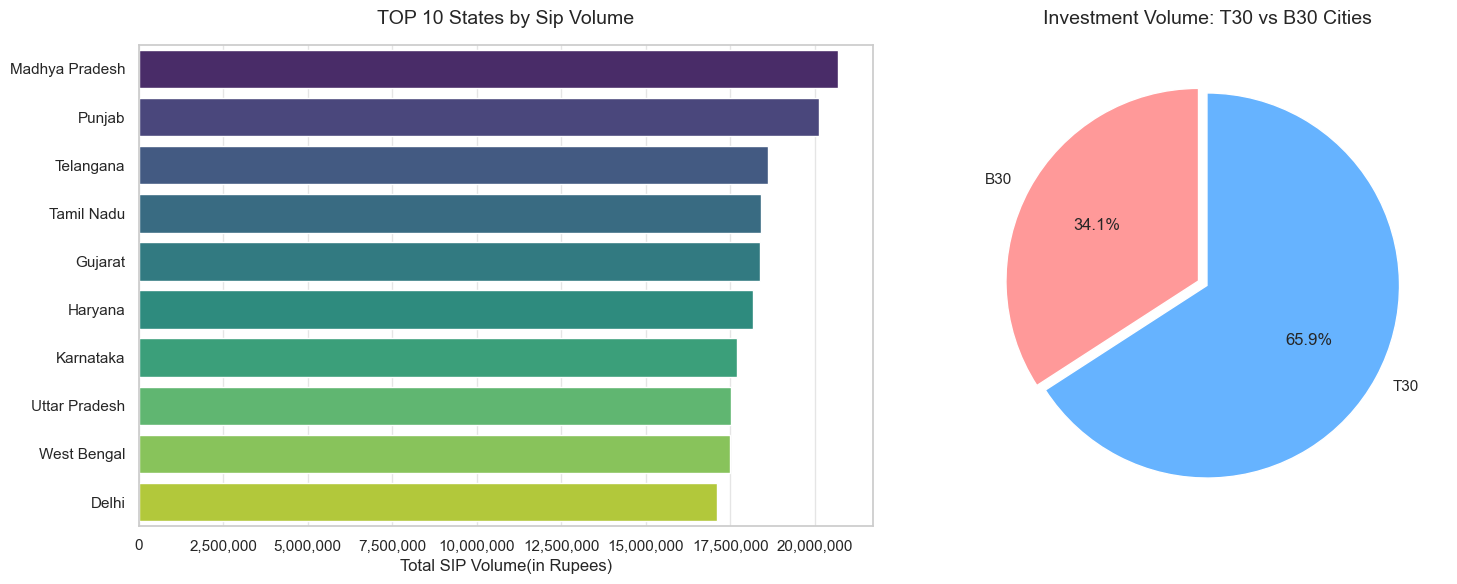

In [9]:
#top 10 states by total_sip_vol

query_state = """
SELECT state,SUM(amount_inr) as total_volume
FROM fact_transactions
where transaction_type = 'Sip'
GROUP BY state
order by total_volume DESC
LIMIT 10
"""

df_state = pd.read_sql(query_state,con)

#T30 vs B30 total_investment_vol
query_tier = """
SELECT city_tier,SUM(amount_inr) as total_volume
FROM fact_transactions
GROUP BY city_tier
"""

df_tier = pd.read_sql(query_tier,con)
fig,axes = plt.subplots(1,2,figsize=(16,6))

sns.barplot(data=df_state,x='total_volume',y='state',ax=axes[0],palette='viridis')
axes[0].set_title('TOP 10 States by Sip Volume',fontsize=14,pad=15)
axes[0].set_xlabel('Total SIP Volume(in Rupees)',fontsize=12)
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,loc: "{:,}".format(int(x))))

axes[1].pie(df_tier['total_volume'],labels=df_tier['city_tier'],autopct='%1.1f%%',startangle=90,colors=['#ff9999','#66b3ff'],explode=(0.05,0))
axes[1].set_title('Investment Volume: T30 vs B30 Cities',fontsize=14,pad=15)

plt.tight_layout()
plt.show()